# 1. Podaci: Novi Sad kao graf

Šta se ovde pokazuje: kako grad postaje instanca problema. Zone, ulična mreža,
matrica tražnje i postojeća GSP mreža koja služi kao referenca.

*(popuniti: odakle podaci, šta je odbačeno i zašto, vidi docs/novi-sad.md)*

In [1]:
import sys
from pathlib import Path

KOREN = Path.cwd().parent
sys.path.insert(0, str(KOREN))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

In [2]:
from tndp.novisad.instanca import ucitaj, gsp_mreza
from tndp.novisad.ulice import ucitaj_zone

city, imena = ucitaj()
zone = ucitaj_zone()
print(f"zona u studiji: {city.n}")
print(f"stanovnika ukupno: {sum(int(z['stanovnika']) for z in zone):,}".replace(",", "."))

zona u studiji: 32
stanovnika ukupno: 293.412


## 1.1 Zone

*(popuniti: zašto mesne zajednice a ne stajališta, zašto gradski a ne prigradski saobraćaj)*

In [3]:
red = sorted(zone, key=lambda z: -int(z["stanovnika"]))
print(f"{'zona':28s} {'stanovnika':>11s} {'km2':>7s} {'stajalista':>11s}")
for z in red[:10]:
    print(f"{z['mz']:28s} {int(z['stanovnika']):11,d} {float(z['povrsina_km2']):7.2f} "
          f"{z['stajalista_gradska']:>11s}".replace(",", "."))

zona                          stanovnika     km2  stajalista
Детелинара                        21.311    1.28          12
Ветерник                          18.847   14.21          11
Бистрица                          17.778    1.46          19
7. Јули                           16.002    1.12          15
Петроварадин                      15.621   25.78          30
Народни хероји                    15.105    0.92           9
Гаврило Принцип                   13.715    1.43          18
Адице                             13.017    4.07           8
Житни трг                         12.696    0.61          11
Југовићево                        12.135    2.71           4


## 1.2 Ulična mreža

Čvor je zona, ivica postoji između zona koje se graniče, težina je vreme vožnje
iz OSM ulične mreže.

*(popuniti: zašto susedstvo a ne puna matrica)*

In [4]:
print("prekrsaji:", city.validate() or "nema")
print(f"ivica: {len(city.street_edges)}, prosecan stepen: {2*len(city.street_edges)/city.n:.1f}")
print(f"MST: {city.mst_time:.1f} min")
print(f"donja granica putnickog vremena: {city.street_shortest_mean_demand:.2f} min")

prekrsaji: nema
ivica: 85, prosecan stepen: 5.3
MST: 62.4 min
donja granica putnickog vremena: 9.18 min


## 1.3 Matrica tražnje

Gravitacioni model: masa je stanovništvo, privlačnost su sadržaji iz OSM-a,
opadanje sa daljinom je `beta`.

*(popuniti: zašto gravitacioni model, zašto merena matrica nije javna)*

ukupno putovanja: 97.070
parova sa traznjom > 0: 187 od 496


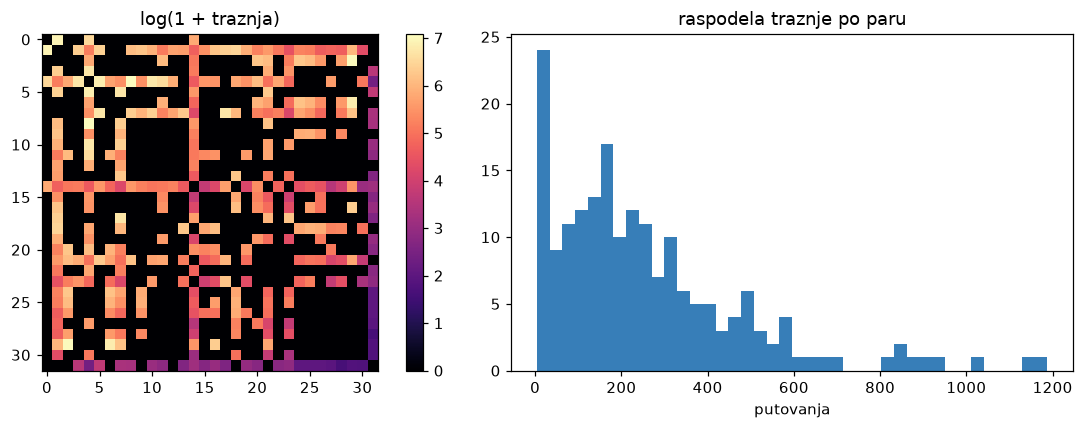

In [5]:
gore = np.triu_indices(city.n, 1)
d = city.demand[gore]
print(f"ukupno putovanja: {city.demand.sum():,.0f}".replace(",", "."))
print(f"parova sa traznjom > 0: {(d > 0).sum()} od {len(d)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(np.log1p(city.demand), cmap="magma")
ax[0].set_title("log(1 + traznja)"); fig.colorbar(im, ax=ax[0])
ax[1].hist(d[d > 0], bins=40, color="#377eb8")
ax[1].set_title("raspodela traznje po paru"); ax[1].set_xlabel("putovanja")
plt.tight_layout()

## 1.4 Kalibracija

Slobodan parametar je pešački prag; `beta` se kalibracijom ne razlikuje.
Detalji i tabela: `results/novisad-kalibracija.md`.

*(popuniti: šta znači da beta nije prepoznatljiva)*

In [6]:
from IPython.display import Markdown
Markdown((KOREN / "results" / "novisad-kalibracija.md").read_text(encoding="utf-8"))

# Kalibracija gravitacione matrice Novog Sada

Slobodan parametar je `beta`, eksponent opadanja tražnje sa daljinom.
Bira se tako da POSTOJEĆA GSP mreža, opterećena tom matricom, da profil
putovanja po linijama najbliži brojanju iz 2017. Mase zona, privlačnost i
rastojanja su mereni i ne podešavaju se.

Intervali sleđenja su iz reda vožnje (vršni sat 13:00-14:00,
radni dan, smer A), ne procenjeni iz opterećenja. Bez toga poređenje ne bi
bilo pošteno: linija 16 ima 89 vožnji dnevno zato što vozi retko, a ne zato
što tražnje nema.

`prag` je rastojanje ispod kog se putovanje obavi peške i ne ulazi u
prevoz. Bez njega beta nije prepoznatljiva , kalibracija je tera na nulu,
jer gravitacioni model bez praga gomila tražnju na susedne zone.

`TV` je ukupno varijaciono rastojanje profila udela (0 = poklapanje, 1 =
disjunktno). `Spearman` je korelacija rangova linija po opterećenju.
Prikazano je 12 najboljih od 220 kombinacija.

| mera rastojanja | beta | prag (km) | TV | Spearman |
|---|---|---|---|---|
| euklidsko | 1.25 | 3.5 | 0.292 | +0.573 |
| euklidsko | 1.00 | 3.5 | 0.292 | +0.573 |
| euklidsko | 1.50 | 3.5 | 0.292 | +0.573 |
| tau | 1.00 | 3.5 | 0.292 | +0.575 |
| tau | 1.25 | 3.5 | 0.292 | +0.575 |
| euklidsko | 0.75 | 3.5 | 0.292 | +0.573 |
| euklidsko | 1.75 | 3.5 | 0.292 | +0.581 |
| tau | 1.50 | 3.5 | 0.292 | +0.556 |
| tau | 0.75 | 3.5 | 0.292 | +0.575 |
| tau | 1.75 | 3.5 | 0.292 | +0.556 |
| euklidsko | 2.00 | 3.5 | 0.292 | +0.604 |
| euklidsko | 0.50 | 3.5 | 0.292 | +0.573 |

Izabrano: **mera = euklidsko, beta = 2.5, prag = 3.5 km** (TV 0.292, Spearman +0.614).

## Šta je kalibracija stvarno odredila

**Prag jeste određen.** TV ima jasan minimum na 3.5 km i raste i ispod
i iznad. 3.5 km je previše za pešačenje i ne treba ga tako čitati , to je
granica ispod koje autobus gubi od pešačenja, bicikla i automobila
zajedno. Novi Sad je ravan i biciklistički, a zone su guste.

**Beta NIJE određena.** Pri pragu 3.5 km je TV jednak na tri decimale za
svaku betu; razlikuje ih tek korelacija rangova, i to u trećoj decimali
(beta 2.5 daje +0.564, beta 2.0 daje +0.554). Kod je zato usvojio
**beta = 2.0**, ne 2.5: razlika je unutar šuma, a 2.0 je vrednost koju
koristi `synth.py`, pa se raspodela tražnje na Novom Sadu ne
razlikuje od one na kojoj je politika trenirana. Isti razlog zbog kog
featuri idu kroz rang transformaciju.

## Profil po linijama pri izabranoj beti

| linija | interval (min) | stvarno | model | razlika |
|---|---|---|---|---|
| 9 | 12.0 | 11.5% | 13.8% | +2.3% |
| 8 | 10.0 | 10.9% | 12.7% | +1.8% |
| 5 | 12.0 | 10.1% | 6.0% | -4.0% |
| 3 | 10.0 | 9.8% | 6.0% | -3.8% |
| 4 | 15.0 | 8.7% | 0.0% | -8.7% |
| 2 | 15.0 | 8.6% | 4.3% | -4.3% |
| 1 | 12.0 | 7.6% | 5.6% | -2.0% |
| 7 | 7.5 | 7.4% | 9.9% | +2.6% |
| 6 | 15.0 | 6.0% | 10.3% | +4.3% |
| 11 | 8.6 | 5.5% | 13.6% | +8.1% |
| 12 | 15.0 | 5.1% | 2.5% | -2.6% |
| 14 | 20.0 | 3.8% | 13.3% | +9.5% |
| 13 | 20.0 | 2.9% | 0.0% | -2.9% |
| 15 | 20.0 | 1.2% | 1.0% | -0.2% |
| 17 | 60.0 | 0.5% | 0.0% | -0.5% |
| 10 | 20.0 | 0.3% | 0.9% | +0.6% |
| 18 | 60.0 | 0.1% | 0.0% | -0.1% |
| 16 | 60.0 | 0.1% | 0.0% | -0.1% |

Nepokrivena tražnja pri toj matrici: 0.000, `C_p` 24.11 min.

## Zašto TV ne pada ispod 0.29

Linije 4, 13, 16, 17, 18 dobijaju TAČNO nula putnika, iako u stvarnosti nose
12.3% prevoza. Uzrok nije matrica tražnje nego dodela: svaki par zona bira
jedan najbrži put i sva tražnja tog para ide na njega, pa među paralelnim
linijama pobednik uzima sve. Stvarni putnik ulazi u onu liniju koja prva
naiđe, pa se opterećenje deli po frekvencijama (Spiess-Florian, strategija
umesto puta). Taj model ovde nije implementiran i to je gornja granica
tačnosti svakog poređenja po linijama u ovom radu.


## 1.5 Postojeća GSP mreža

Referenca sa kojom se model poredi. 19 osnovnih gradskih linija prevedenih u zone.

*(popuniti: kako je trasa prevedena u zonski graf i šta se pri tom izgubilo)*

In [7]:
gsp, dnevnik = gsp_mreza(city, imena)
duz = [len(r) for r in gsp.routes]
print(f"linija: {len(gsp.routes)}, duzina min {min(duz)} / medijana {int(np.median(duz))} / max {max(duz)}")
print(f"prekrsaji: {gsp.check(city, len(gsp.routes), min(duz), max(duz)) or 'nema'}")
for d_ in dnevnik[:8]:
    print(f"  {d_['linija']:>3} {d_['zona_sirovo']:3d} -> {d_['zona_trasa']:2d} zona   {d_['naziv'][:42]}")

linija: 19, duzina min 2 / medijana 8 / max 14
prekrsaji: nema
    1  15 ->  8 zona   KLISA - CENTAR - LIMAN 1
    2  11 ->  7 zona   NOVO NASELJE - CENTAR
    3   9 ->  7 zona   DETELINARA - CENTAR - PETROVARADIN
    4  10 -> 11 zona   LIMAN 4 - CENTAR - ŽELEZNIČKA STANICA
    5  17 -> 10 zona   ŽELEZNIČKA STANICA - NAJLON - TEMERINSKI P
    6  20 -> 11 zona   ADICE-CENTAR-PODBARA
    7  16 -> 14 zona   NOVO NASELJE - ŽELEZNIČKA STANICA -FUTOŠKA
    8  22 -> 11 zona   NOVO NASELJE - CENTAR - LIMAN 1


-> D:\faks\Seminarski rad D\results\novisad-rl.png


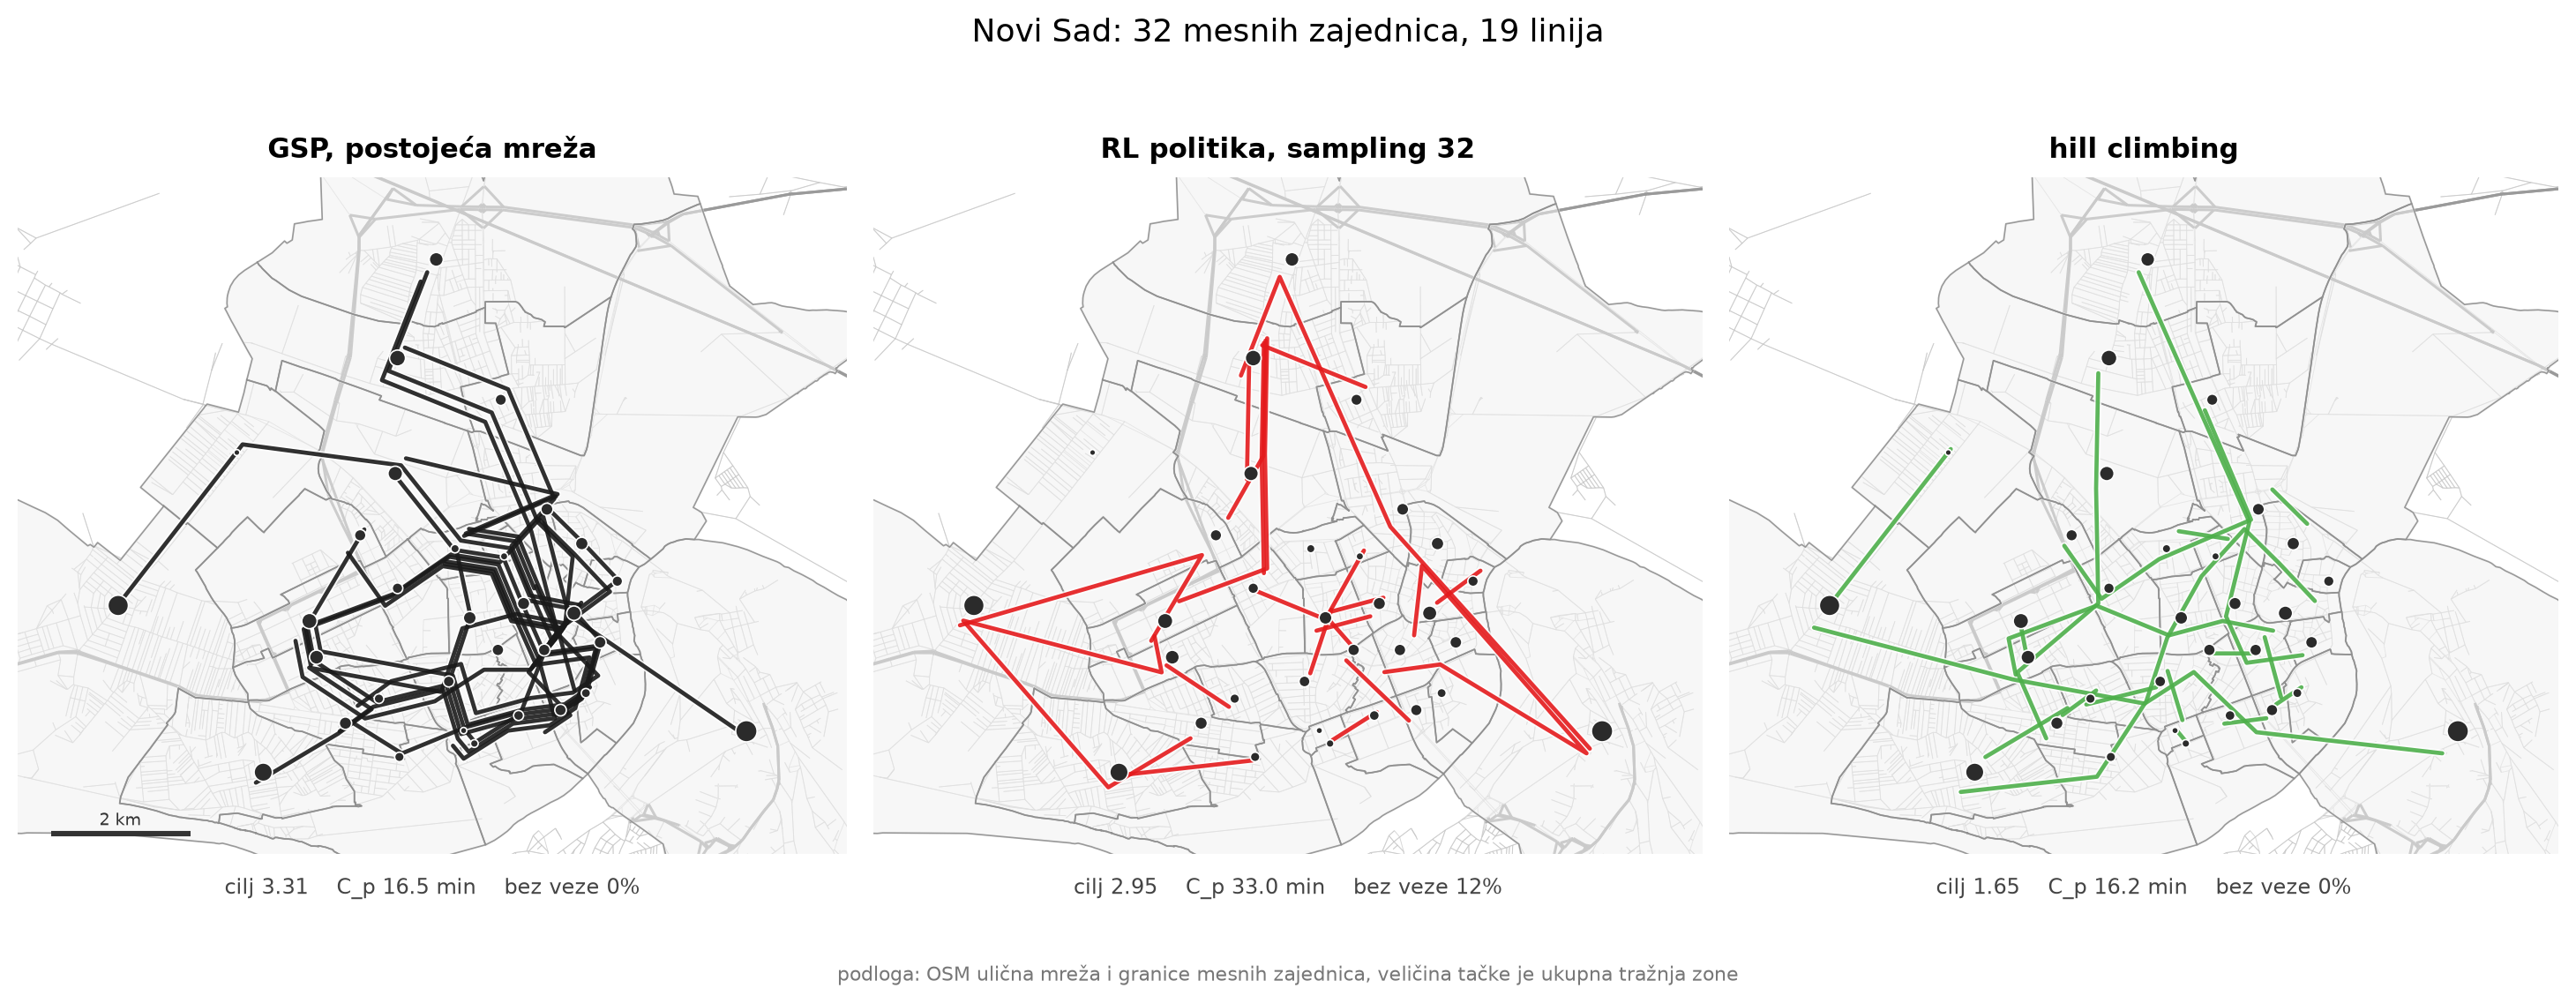

In [8]:
from tndp.novisad import karta
karta.main()

from IPython.display import Image
Image(str(KOREN / "results" / "novisad-rl.png"))

## Zaključci

*(popuniti)*